In [11]:
install.packages(c("lavaan", "psych", "GPArotation", "semPlot"))
library(lavaan)
library(psych)
library(GPArotation)
library(semPlot)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# VERİ

In [12]:
data(PoliticalDemocracy)
d <- PoliticalDemocracy
set.seed(42)
idx <- sample(nrow(d), floor(nrow(d) / 2))
d_efa <- d[idx, ]
d_cfa <- d[-idx, ]
dim(d_efa)
dim(d_cfa)

[1] 37 11

[1] 38 11

# MODEL-DEĞERLENDİRME (EFA)

In [13]:
R <- cor(d_efa)
lambda <- eigen(R)$values
lambda
nf <- sum(lambda > 1)
nf
efa <- principal(r = R, nfactors = nf, rotate = "varimax", n.obs = nrow(d_efa))
print(efa$loadings, cutoff = 0.30)
efa$Vaccounted

[1] 6.39216424 1.88754390 0.79640358 0.51692191 0.42183337 0.28494192
 [7] 0.22932495 0.17411299 0.12845370 0.08465230 0.08364713

[1] 2


Loadings:
   RC1    RC2   
y1  0.808       
y2  0.752       
y3  0.726       
y4  0.826       
y5  0.748  0.306
y6  0.780  0.331
y7  0.864  0.303
y8  0.857       
x1         0.928
x2         0.935
x3         0.903

                 RC1   RC2
SS loadings    5.212 3.067
Proportion Var 0.474 0.279
Cumulative Var 0.474 0.753


,RC1,RC2
SS loadings,5.2124088,3.0672993
Proportion Var,0.4738553,0.2788454
Cumulative Var,0.4738553,0.7527007
Proportion Explained,0.6295402,0.3704598
Cumulative Proportion,0.6295402,1.0000000


# MODEL-DEĞERLENDİRME (CFA)

In [14]:
model_cfa <- '
  F1 =~ x1 + x2 + x3
  F2 =~ y1 + y2 + y3 + y4
  F3 =~ y5 + y6 + y7 + y8
'
fit_cfa <- cfa(model_cfa, data = d_cfa, estimator = "ML")
summary(fit_cfa, fit.measures = TRUE, standardized = TRUE)
fitMeasures(fit_cfa, c("chisq", "df", "pvalue", "rmsea", "cfi", "tli", "srmr"))

lhs,op,rhs,exo,est,se,z,pvalue,std.lv,std.all
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
F1,=~,x1,0,1.00000000,0.00000000,NA,NA,0.67897197,0.93003314
F1,=~,x2,0,2.16784639,0.18479170,11.731297,0.000000e+00,1.47190693,0.97344151
F1,=~,x3,0,1.72996749,0.20710469,8.353106,0.000000e+00,1.17459943,0.85722026
F2,=~,y1,0,1.00000000,0.00000000,NA,NA,2.57421025,0.90623198
F2,=~,y2,0,1.14593067,0.19102859,5.998739,1.988555e-09,2.94986649,0.75599835
F2,=~,y3,0,0.98476674,0.13940871,7.063882,1.619149e-12,2.53499664,0.82447796
F2,=~,y4,0,1.10562530,0.13985648,7.905428,2.664535e-15,2.84611197,0.86905680
F3,=~,y5,0,1.00000000,0.00000000,NA,NA,2.23945830,0.85249655
F3,=~,y6,0,1.04831579,0.21109805,4.966014,6.834315e-07,2.34765949,0.69756683


chisq     df pvalue  rmsea    cfi    tli   srmr 
83.556 41.000  0.000  0.165  0.886  0.847  0.095

# MODEL-DEĞERLENDİRME (SEM)

lhs,op,rhs,label,exo,est,se,z,pvalue,std.lv,std.all
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
F1,=~,x1,,0,1.00000000,0.00000000,NA,NA,0.67897484,0.93003379
F1,=~,x2,,0,2.16784423,0.18479063,11.7313538,0.000000e+00,1.47191169,0.97344152
F1,=~,x3,,0,1.72996576,0.20710362,8.3531409,0.000000e+00,1.17460322,0.85722110
F2,=~,y1,,0,1.00000000,0.00000000,NA,NA,2.57422084,0.90623282
F2,=~,y2,,0,1.14593031,0.19102759,5.9987687,1.988193e-09,2.94987768,0.75599984
F2,=~,y3,,0,0.98476567,0.13940805,7.0639079,1.618927e-12,2.53500430,0.82447862
F2,=~,y4,,0,1.10562428,0.13985589,7.9054541,2.664535e-15,2.84612107,0.86905713
F3,=~,y5,,0,1.00000000,0.00000000,NA,NA,2.23946570,0.85249735
F3,=~,y6,,0,1.04831719,0.21109762,4.9660303,6.833729e-07,2.34767038,0.69756791


chisq     df pvalue  rmsea    cfi    tli   srmr 
83.556 41.000  0.000  0.165  0.886  0.847  0.095

lhs,op,rhs,label,est,se,z,pvalue,ci.lower,ci.upper
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
F1,=~,x1,,1.00000000,0.00000000,NA,NA,1.00000000,1.0000000
F1,=~,x2,,2.16784423,0.18479063,11.7313538,0.000000e+00,1.80566126,2.5300272
F1,=~,x3,,1.72996576,0.20710362,8.3531409,0.000000e+00,1.32405011,2.1358814
F2,=~,y1,,1.00000000,0.00000000,NA,NA,1.00000000,1.0000000
F2,=~,y2,,1.14593031,0.19102759,5.9987687,1.988193e-09,0.77152312,1.5203375
F2,=~,y3,,0.98476567,0.13940805,7.0639079,1.618927e-12,0.71153090,1.2580004
F2,=~,y4,,1.10562428,0.13985589,7.9054541,2.664535e-15,0.83151178,1.3797368
F3,=~,y5,,1.00000000,0.00000000,NA,NA,1.00000000,1.0000000
F3,=~,y6,,1.04831719,0.21109762,4.9660303,6.833729e-07,0.63457345,1.4620609


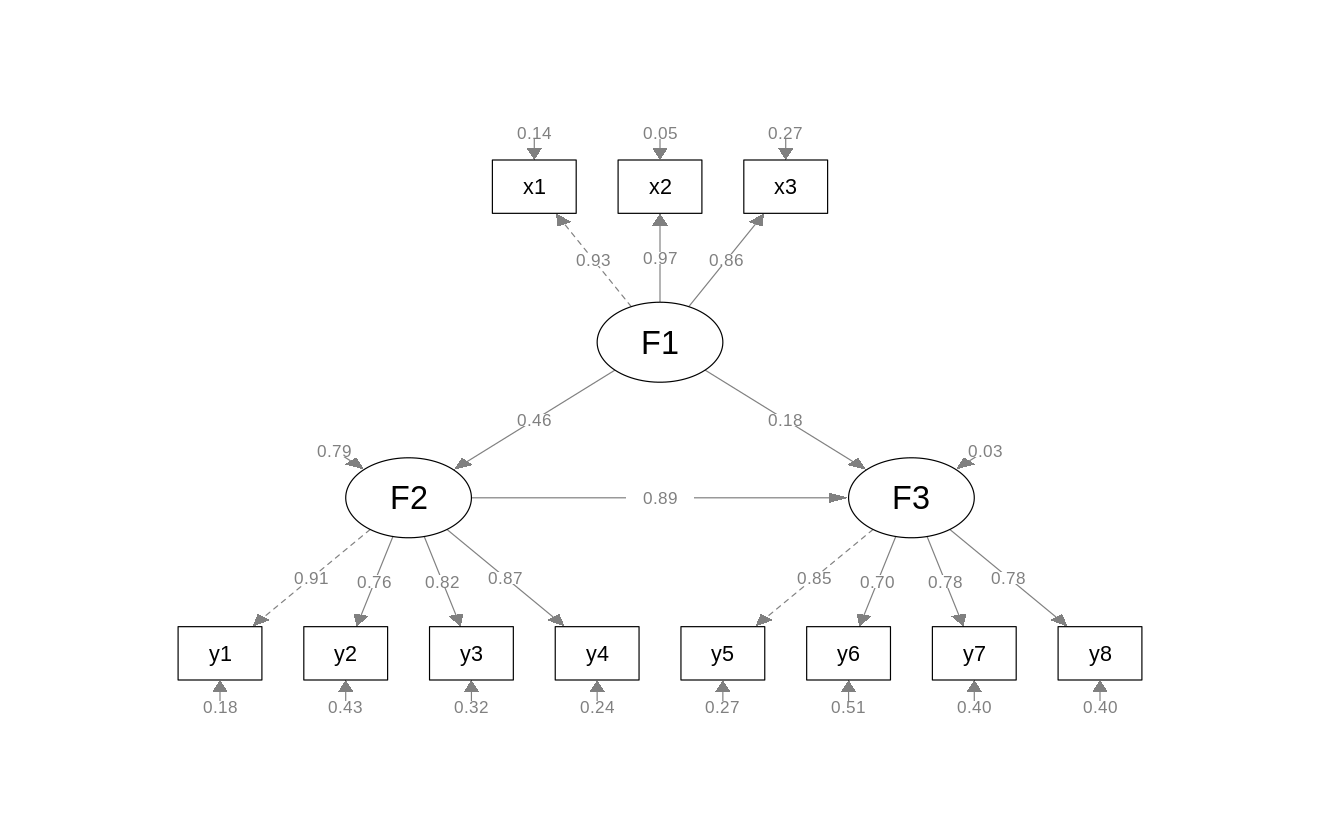

In [15]:
model_sem <- '
  F1 =~ x1 + x2 + x3
  F2 =~ y1 + y2 + y3 + y4
  F3 =~ y5 + y6 + y7 + y8

  F2 ~ a*F1
  F3 ~ c*F1 + b*F2

  DE := c
  IE := a*b
  TE := c + a*b
'
fit_sem <- sem(model_sem, data = d_cfa, estimator = "ML")
summary(fit_sem, fit.measures = TRUE, standardized = TRUE, rsquare = TRUE)
fitMeasures(fit_sem, c("chisq", "df", "pvalue", "rmsea", "cfi", "tli", "srmr"))
parameterEstimates(fit_sem, ci = TRUE)

options(repr.plot.width = 11, repr.plot.height = 7)
semPaths(fit_sem,
         whatLabels = "std",
         layout = "tree2",
         style = "lisrel",
         edge.label.cex = 0.9,
         nCharNodes = 0,
         sizeLat = 9,
         sizeMan = 6)